# DATA 266 Lab 1 — Task 1
## GPT-Style Language Model from Scratch on TinyStories

**Student:** Naveen Aravapalli  
**Task:** Character-level autoregressive language modeling  
**Dataset:** TinyStories  
**Hardware:** NVIDIA GeForce RTX 5090  

### Assignment Requirements
- Character-level tokenization
- Custom `char_to_idx` and `idx_to_char`
- 100,000 training stories
- 10,000 validation stories
- Transformer implementation from scratch
- Multi-head causal self-attention
- Learnable token and positional embeddings
- Minimum 10 training epochs
- Text generation and failure analysis

In [3]:
%pip install ipywidgets

   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 2.2/2.2 MB 63.3 MB/s  0:00:00

   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   ---------------------------------------- 3/3 [ipywidgets]

Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import sys
import time
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from datasets import load_dataset
from tqdm.auto import tqdm

# Reproducibility seed
SEED = 171

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "VRAM:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

Python: 3.12.14
PyTorch: 2.13.0+cu130
Device: cuda
GPU: NVIDIA GeForce RTX 5090
VRAM: 31.84 GB


In [6]:
from pathlib import Path

# Current notebook location:
# D:\DATA266_Lab1\task1_llm\naveen\src

SRC_DIR = Path.cwd()
MEMBER_DIR = SRC_DIR.parent
TASK_DIR = MEMBER_DIR.parent
PROJECT_ROOT = TASK_DIR.parent

DATA_DIR = TASK_DIR / "data"
CHECKPOINT_DIR = MEMBER_DIR / "checkpoints"
OUTPUT_DIR = MEMBER_DIR / "outputs"
PROCESSED_DIR = MEMBER_DIR / "data_processed"

for folder in [
    DATA_DIR,
    CHECKPOINT_DIR,
    OUTPUT_DIR,
    PROCESSED_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Source directory    :", SRC_DIR)
print("Member directory    :", MEMBER_DIR)
print("Task directory      :", TASK_DIR)
print("Project root        :", PROJECT_ROOT)
print("Data directory      :", DATA_DIR)
print("Checkpoint directory:", CHECKPOINT_DIR)
print("Output directory    :", OUTPUT_DIR)
print("Processed directory :", PROCESSED_DIR)

Source directory    : D:\DATA266_Lab1\task1_llm\naveen\src
Member directory    : D:\DATA266_Lab1\task1_llm\naveen
Task directory      : D:\DATA266_Lab1\task1_llm
Project root        : D:\DATA266_Lab1
Data directory      : D:\DATA266_Lab1\task1_llm\data
Checkpoint directory: D:\DATA266_Lab1\task1_llm\naveen\checkpoints
Output directory    : D:\DATA266_Lab1\task1_llm\naveen\outputs
Processed directory : D:\DATA266_Lab1\task1_llm\naveen\data_processed


In [8]:
from datasets import load_dataset

print("Loading TinyStories...")

dataset = load_dataset(
    "roneneldan/TinyStories",
    split="train"
)

print("\nDataset loaded.")
print(dataset)
print("Total stories:", len(dataset))
print("Columns:", dataset.column_names)

Loading TinyStories...

Dataset loaded.
Dataset({
    features: ['text'],
    num_rows: 2119719
})
Total stories: 2119719
Columns: ['text']


In [9]:
sample_text = dataset[0]["text"]

print("Sample story length:", len(sample_text))
print("\n--- SAMPLE STORY ---\n")
print(sample_text[:1500])

Sample story length: 701

--- SAMPLE STORY ---

One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

Together, they shared the needle and sewed the button on Lily's shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.


In [10]:
# Personal deterministic split for this member
# Assignment requirement:
# 100,000 training stories + 10,000 validation stories

SHUFFLE_SEED = SEED

shuffled_dataset = dataset.shuffle(seed=SHUFFLE_SEED)

train_stories = shuffled_dataset.select(range(0, 100_000))
val_stories = shuffled_dataset.select(range(100_000, 110_000))

print("Training stories  :", len(train_stories))
print("Validation stories:", len(val_stories))

assert len(train_stories) == 100_000
assert len(val_stories) == 10_000

print("\nSplit verification PASSED.")

Training stories  : 100000
Validation stories: 10000

Split verification PASSED.


In [11]:
print("--- TRAIN SAMPLE ---")
print(train_stories[0]["text"][:500])

print("\n--- VALIDATION SAMPLE ---")
print(val_stories[0]["text"][:500])

--- TRAIN SAMPLE ---
Once upon a time, there were two friends, Jack and Jill. They had lots of fun together every day. One day the sun was shining, so they decided to play outside.

They both snapped their fingers and laughed. Suddenly Jack had a great idea. "Let's go to the park!" he said. 

Jill was excited.  "Yay!" she said.

They quickly ran to the park. They ran and ran until they arrived. The park was so much fun for them.

They saw a big slide and went on it together. They'd climb up, snap their fingers and s

--- VALIDATION SAMPLE ---
Once upon a time, there were two friends, Penny and Jared. They were outside one day, playing together when they saw a mailbox. They both had the same thought and decided to discuss it. 

Jared said to Penny, "I think we should try to open the mailbox." 

Penny replied, "That's a stupid idea. It's not ours, and we could get into lots of trouble!" 

Jared insisted, "But it would be fun! We'd get to see what's inside." 

Penny gave in, "Okay, but if

In [12]:
print("Building character vocabulary from training data...")

train_characters = set()

for story in tqdm(train_stories, desc="Scanning training stories"):
    train_characters.update(story["text"])

chars = sorted(train_characters)

char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

VOCAB_SIZE = len(chars)

print("\nVocabulary size:", VOCAB_SIZE)
print("First 30 vocabulary entries:")
print(chars[:30])

Building character vocabulary from training data...


Scanning training stories: 100%|██████████| 100000/100000 [00:02<00:00, 33657.48it/s]


Vocabulary size: 109
First 30 vocabulary entries:
['\t', '\n', ' ', '!', '"', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '=']


In [13]:
val_characters = set()

for story in tqdm(val_stories, desc="Scanning validation stories"):
    val_characters.update(story["text"])

unseen_chars = sorted(val_characters - train_characters)

print("Unique training characters   :", len(train_characters))
print("Unique validation characters :", len(val_characters))
print("Validation-only characters   :", len(unseen_chars))

if unseen_chars:
    print("\nUnseen characters:")
    print(repr(unseen_chars))
else:
    print("\nNo unseen validation characters. Good!")

Scanning validation stories: 100%|██████████| 10000/10000 [00:00<00:00, 26790.34it/s]

Unique training characters   : 109
Unique validation characters : 89
Validation-only characters   : 3

Unseen characters:
['¼', '¿', 'ï']


In [14]:
# Reserve one token for characters that were not seen in training
UNK_TOKEN = "<UNK>"
UNK_IDX = len(char_to_idx)

char_to_idx[UNK_TOKEN] = UNK_IDX
idx_to_char[UNK_IDX] = UNK_TOKEN

VOCAB_SIZE = len(char_to_idx)

print("Original character vocabulary:", len(train_characters))
print("UNK index:", UNK_IDX)
print("Final vocabulary size:", VOCAB_SIZE)

Original character vocabulary: 109
UNK index: 109
Final vocabulary size: 110


In [15]:
from collections import Counter

unseen_counter = Counter()

for story in val_stories:
    for ch in story["text"]:
        if ch not in train_characters:
            unseen_counter[ch] += 1

print("Validation-only character counts:")

for ch, count in unseen_counter.items():
    print(repr(ch), "->", count)

print("\nTotal unseen character occurrences:", sum(unseen_counter.values()))

Validation-only character counts:
'ï' -> 1
'¿' -> 1
'¼' -> 1

Total unseen character occurrences: 3


In [16]:
def encode(text):
    """
    Convert text into integer token IDs.
    Characters not present in the training vocabulary map to <UNK>.
    """
    return [char_to_idx.get(ch, UNK_IDX) for ch in text]


def decode(indices):
    """
    Convert integer token IDs back into text.
    """
    return "".join(idx_to_char[int(i)] for i in indices)


# Quick tokenizer test
test_text = "Once upon a time!"

encoded_test = encode(test_text)
decoded_test = decode(encoded_test)

print("Original:", test_text)
print("Encoded :", encoded_test)
print("Decoded :", decoded_test)

assert decoded_test == test_text

print("\nTokenizer round-trip test PASSED.")

Original: Once upon a time!
Encoded : [45, 75, 64, 66, 2, 82, 77, 76, 75, 2, 62, 2, 81, 70, 74, 66, 3]
Decoded : Once upon a time!

Tokenizer round-trip test PASSED.


In [17]:
print("Combining stories into text streams...")

train_text = "\n\n".join(train_stories["text"])
val_text = "\n\n".join(val_stories["text"])

print("Training characters  :", f"{len(train_text):,}")
print("Validation characters:", f"{len(val_text):,}")

print("\nTraining preview:")
print(train_text[:500])

Combining stories into text streams...
Training characters  : 89,733,070
Validation characters: 8,954,303

Training preview:
Once upon a time, there were two friends, Jack and Jill. They had lots of fun together every day. One day the sun was shining, so they decided to play outside.

They both snapped their fingers and laughed. Suddenly Jack had a great idea. "Let's go to the park!" he said. 

Jill was excited.  "Yay!" she said.

They quickly ran to the park. They ran and ran until they arrived. The park was so much fun for them.

They saw a big slide and went on it together. They'd climb up, snap their fingers and s


In [18]:
print("Encoding training corpus...")

train_ids_np = np.fromiter(
    (char_to_idx.get(ch, UNK_IDX) for ch in train_text),
    dtype=np.uint8,
    count=len(train_text)
)

print("Encoding validation corpus...")

val_ids_np = np.fromiter(
    (char_to_idx.get(ch, UNK_IDX) for ch in val_text),
    dtype=np.uint8,
    count=len(val_text)
)

train_ids = torch.from_numpy(train_ids_np)
val_ids = torch.from_numpy(val_ids_np)

print("\nTrain tensor shape:", train_ids.shape)
print("Validation tensor shape:", val_ids.shape)

print("Train dtype:", train_ids.dtype)
print("Validation dtype:", val_ids.dtype)

print(
    "Train storage:",
    round(train_ids.numel() * train_ids.element_size() / 1024**2, 2),
    "MB"
)

print(
    "Validation storage:",
    round(val_ids.numel() * val_ids.element_size() / 1024**2, 2),
    "MB"
)

Encoding training corpus...
Encoding validation corpus...

Train tensor shape: torch.Size([89733070])
Validation tensor shape: torch.Size([8954303])
Train dtype: torch.uint8
Validation dtype: torch.uint8
Train storage: 85.58 MB
Validation storage: 8.54 MB


In [19]:
print("First 200 decoded training characters:\n")
print(decode(train_ids[:200]))

print("\nMaximum training token ID:", int(train_ids.max()))
print("Maximum validation token ID:", int(val_ids.max()))
print("Vocabulary size:", VOCAB_SIZE)

assert int(train_ids.max()) < VOCAB_SIZE
assert int(val_ids.max()) < VOCAB_SIZE

print("\nEncoded corpus validation PASSED.")

First 200 decoded training characters:

Once upon a time, there were two friends, Jack and Jill. They had lots of fun together every day. One day the sun was shining, so they decided to play outside.

They both snapped their fingers and lau

Maximum training token ID: 108
Maximum validation token ID: 109
Vocabulary size: 110

Encoded corpus validation PASSED.


In [20]:
train_ids_path = PROCESSED_DIR / "train_ids.npy"
val_ids_path = PROCESSED_DIR / "val_ids.npy"

np.save(train_ids_path, train_ids.numpy())
np.save(val_ids_path, val_ids.numpy())

print("Saved:")
print(train_ids_path)
print(val_ids_path)

print("\nTrain file MB:", round(train_ids_path.stat().st_size / 1024**2, 2))
print("Val file MB  :", round(val_ids_path.stat().st_size / 1024**2, 2))

Saved:
D:\DATA266_Lab1\task1_llm\naveen\data_processed\train_ids.npy
D:\DATA266_Lab1\task1_llm\naveen\data_processed\val_ids.npy

Train file MB: 85.58
Val file MB  : 8.54


In [21]:
from torch.utils.data import Dataset, DataLoader


class CharSequenceDataset(Dataset):
    """
    Creates fixed-length autoregressive character sequences.

    Input:
        tokens[i : i + block_size]

    Target:
        tokens[i + 1 : i + block_size + 1]
    """

    def __init__(self, token_ids, block_size, stride=None):
        self.token_ids = token_ids
        self.block_size = block_size

        # Default to non-overlapping windows for efficient training
        self.stride = stride if stride is not None else block_size

        self.num_sequences = (
            (len(self.token_ids) - block_size - 1) // self.stride
        ) + 1


    def __len__(self):
        return self.num_sequences


    def __getitem__(self, idx):
        start = idx * self.stride
        end = start + self.block_size

        x = self.token_ids[start:end].long()
        y = self.token_ids[start + 1:end + 1].long()

        return x, y

In [22]:
BLOCK_SIZE = 256

train_dataset = CharSequenceDataset(
    train_ids,
    block_size=BLOCK_SIZE
)

val_dataset = CharSequenceDataset(
    val_ids,
    block_size=BLOCK_SIZE
)

print("Block size          :", BLOCK_SIZE)
print("Training sequences  :", f"{len(train_dataset):,}")
print("Validation sequences:", f"{len(val_dataset):,}")

Block size          : 256
Training sequences  : 350,519
Validation sequences: 34,977


In [23]:
x, y = train_dataset[0]

print("Input shape :", x.shape)
print("Target shape:", y.shape)

print("\nINPUT:")
print(decode(x[:150]))

print("\nTARGET:")
print(decode(y[:150]))

print("\nFirst 10 input IDs :", x[:10].tolist())
print("First 10 target IDs:", y[:10].tolist())

Input shape : torch.Size([256])
Target shape: torch.Size([256])

INPUT:
Once upon a time, there were two friends, Jack and Jill. They had lots of fun together every day. One day the sun was shining, so they decided to play

TARGET:
nce upon a time, there were two friends, Jack and Jill. They had lots of fun together every day. One day the sun was shining, so they decided to play 

First 10 input IDs : [45, 75, 64, 66, 2, 82, 77, 76, 75, 2]
First 10 target IDs: [75, 64, 66, 2, 82, 77, 76, 75, 2, 62]


In [24]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    drop_last=False
)

print("Batch size:", BATCH_SIZE)
print("Training batches per epoch  :", len(train_loader))
print("Validation batches per epoch:", len(val_loader))

Batch size: 128
Training batches per epoch  : 2738
Validation batches per epoch: 274


In [25]:
xb, yb = next(iter(train_loader))

print("Input batch shape :", xb.shape)
print("Target batch shape:", yb.shape)
print("Input dtype       :", xb.dtype)
print("Target dtype      :", yb.dtype)

print("\nExpected shape:")
print(f"[batch_size, block_size] = [{BATCH_SIZE}, {BLOCK_SIZE}]")

assert xb.shape == yb.shape
assert xb.shape[1] == BLOCK_SIZE
assert xb.dtype == torch.int64

print("\nDataLoader verification PASSED.")

Input batch shape : torch.Size([128, 256])
Target batch shape: torch.Size([128, 256])
Input dtype       : torch.int64
Target dtype      : torch.int64

Expected shape:
[batch_size, block_size] = [128, 256]

DataLoader verification PASSED.


## Model Configuration

I selected a balanced GPT configuration with a context length of 256 characters.
This provides enough context to span multiple sentences in TinyStories while keeping
the quadratic cost of self-attention manageable.

The model uses:
- Context length: 256
- Embedding dimension: 256
- Attention heads: 8
- Transformer blocks: 4
- Dropout: 0.10
- Batch size: 128
- Initial learning rate: 3e-4
- Training epochs: 10

With 8 attention heads and a 256-dimensional embedding, each head operates on
32-dimensional query, key, and value representations.

In [46]:
# ============================================================
# GPT configuration
# ============================================================

BLOCK_SIZE = 256
BATCH_SIZE = 128

N_EMBD = 256
N_HEAD = 8
N_LAYER = 4
DROPOUT = 0.10

LEARNING_RATE = 3e-4
MIN_LR = 3e-5
WEIGHT_DECAY = 0.01

EPOCHS = 10
WARMUP_STEPS = 500

assert N_EMBD % N_HEAD == 0

HEAD_SIZE = N_EMBD // N_HEAD

print("Context length      :", BLOCK_SIZE)
print("Embedding dimension :", N_EMBD)
print("Attention heads     :", N_HEAD)
print("Dimension per head  :", HEAD_SIZE)
print("Transformer blocks  :", N_LAYER)
print("Dropout              :", DROPOUT)
print("Batch size           :", BATCH_SIZE)
print("Epochs               :", EPOCHS)

Context length      : 256
Embedding dimension : 256
Attention heads     : 8
Dimension per head  : 32
Transformer blocks  : 4
Dropout              : 0.1
Batch size           : 128
Epochs               : 10


In [47]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    drop_last=False
)

print("Training batches per epoch  :", len(train_loader))
print("Validation batches per epoch:", len(val_loader))

Training batches per epoch  : 2738
Validation batches per epoch: 274


In [48]:
xb, yb = next(iter(train_loader))

print("Input batch :", xb.shape)
print("Target batch:", yb.shape)
print("Input dtype :", xb.dtype)

assert xb.shape == (BATCH_SIZE, BLOCK_SIZE)
assert yb.shape == (BATCH_SIZE, BLOCK_SIZE)
assert xb.dtype == torch.int64

print("\nDataLoader verification PASSED.")

Input batch : torch.Size([128, 256])
Target batch: torch.Size([128, 256])
Input dtype : torch.int64

DataLoader verification PASSED.


In [49]:
class CausalMultiHeadSelfAttention(nn.Module):
    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()

        assert n_embd % n_head == 0

        self.n_embd = n_embd
        self.n_head = n_head
        self.head_size = n_embd // n_head

        # One projection each for query, key and value
        self.query = nn.Linear(n_embd, n_embd, bias=False)
        self.key = nn.Linear(n_embd, n_embd, bias=False)
        self.value = nn.Linear(n_embd, n_embd, bias=False)

        # Projection after concatenating all attention heads
        self.proj = nn.Linear(n_embd, n_embd)

        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)

        # Lower-triangular causal mask
        mask = torch.tril(
            torch.ones(block_size, block_size)
        )

        self.register_buffer(
            "causal_mask",
            mask.view(1, 1, block_size, block_size)
        )

    def forward(self, x):
        B, T, C = x.shape

        # ----------------------------------------------------
        # 1. Compute Q, K and V
        # ----------------------------------------------------
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)

        # ----------------------------------------------------
        # 2. Split embedding dimension into multiple heads
        #
        # [B, T, C]
        #       ↓
        # [B, n_head, T, head_size]
        # ----------------------------------------------------
        q = q.view(B, T, self.n_head, self.head_size).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_size).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_size).transpose(1, 2)

        # ----------------------------------------------------
        # 3. Scaled dot-product attention
        # ----------------------------------------------------
        scale = self.head_size ** -0.5

        attention_scores = (q @ k.transpose(-2, -1)) * scale

        # ----------------------------------------------------
        # 4. Causal masking
        #
        # Prevent position t from attending to positions > t
        # ----------------------------------------------------
        attention_scores = attention_scores.masked_fill(
            self.causal_mask[:, :, :T, :T] == 0,
            float("-inf")
        )

        # ----------------------------------------------------
        # 5. Convert scores into attention probabilities
        # ----------------------------------------------------
        attention_weights = F.softmax(
            attention_scores,
            dim=-1
        )

        attention_weights = self.attn_dropout(attention_weights)

        # ----------------------------------------------------
        # 6. Weighted sum of values
        # ----------------------------------------------------
        out = attention_weights @ v

        # [B, n_head, T, head_size]
        #            ↓
        # [B, T, C]
        out = (
            out.transpose(1, 2)
               .contiguous()
               .view(B, T, C)
        )

        # Final output projection
        out = self.proj(out)
        out = self.resid_dropout(out)

        return out

In [50]:
attention_test = CausalMultiHeadSelfAttention(
    n_embd=N_EMBD,
    n_head=N_HEAD,
    block_size=BLOCK_SIZE,
    dropout=DROPOUT
).to(device)

dummy_x = torch.randn(
    2,
    BLOCK_SIZE,
    N_EMBD,
    device=device
)

with torch.no_grad():
    dummy_out = attention_test(dummy_x)

print("Input shape :", dummy_x.shape)
print("Output shape:", dummy_out.shape)

assert dummy_out.shape == dummy_x.shape

print("\nCausal multi-head attention test PASSED.")

Input shape : torch.Size([2, 256, 256])
Output shape: torch.Size([2, 256, 256])

Causal multi-head attention test PASSED.


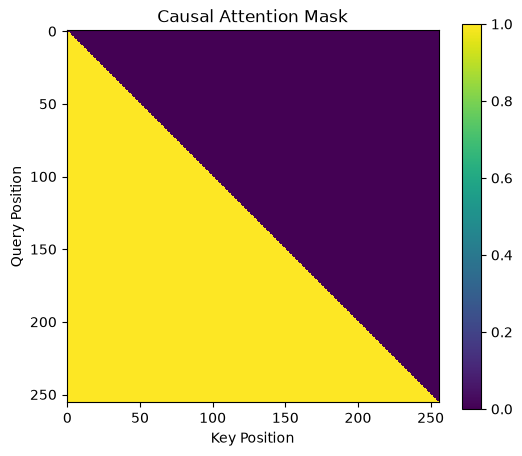

In [51]:
plt.figure(figsize=(6, 5))

plt.imshow(
    attention_test.causal_mask[0, 0].cpu(),
    interpolation="nearest"
)

plt.title("Causal Attention Mask")
plt.xlabel("Key Position")
plt.ylabel("Query Position")
plt.colorbar()
plt.show()

In [52]:
class FeedForward(nn.Module):
    def __init__(self, n_embd, dropout):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

In [53]:
class TransformerBlock(nn.Module):
    def __init__(
        self,
        n_embd,
        n_head,
        block_size,
        dropout
    ):
        super().__init__()

        self.ln1 = nn.LayerNorm(n_embd)

        self.attention = CausalMultiHeadSelfAttention(
            n_embd=n_embd,
            n_head=n_head,
            block_size=block_size,
            dropout=dropout
        )

        self.ln2 = nn.LayerNorm(n_embd)

        self.ffn = FeedForward(
            n_embd=n_embd,
            dropout=dropout
        )

    def forward(self, x):

        # Attention + residual connection
        x = x + self.attention(self.ln1(x))

        # Feed-forward + residual connection
        x = x + self.ffn(self.ln2(x))

        return x

In [54]:
block_test = TransformerBlock(
    n_embd=N_EMBD,
    n_head=N_HEAD,
    block_size=BLOCK_SIZE,
    dropout=DROPOUT
).to(device)

dummy_x = torch.randn(
    2,
    BLOCK_SIZE,
    N_EMBD,
    device=device
)

with torch.no_grad():
    dummy_out = block_test(dummy_x)

print("Transformer input :", dummy_x.shape)
print("Transformer output:", dummy_out.shape)

assert dummy_x.shape == dummy_out.shape

print("\nTransformer block test PASSED.")

Transformer input : torch.Size([2, 256, 256])
Transformer output: torch.Size([2, 256, 256])

Transformer block test PASSED.


In [55]:
class GPTLanguageModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        block_size,
        n_embd,
        n_head,
        n_layer,
        dropout
    ):
        super().__init__()

        self.block_size = block_size

        # Learnable token + positional embeddings
        self.token_embedding = nn.Embedding(vocab_size, n_embd)
        self.position_embedding = nn.Embedding(block_size, n_embd)

        # Transformer stack
        self.blocks = nn.ModuleList([
            TransformerBlock(
                n_embd=n_embd,
                n_head=n_head,
                block_size=block_size,
                dropout=dropout
            )
            for _ in range(n_layer)
        ])

        self.ln_f = nn.LayerNorm(n_embd)

        # Project hidden representations to vocabulary logits
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

            if module.bias is not None:
                nn.init.zeros_(module.bias)

        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        if T > self.block_size:
            raise ValueError(
                f"Sequence length {T} exceeds block size "
                f"{self.block_size}"
            )

        positions = torch.arange(
            0, T, device=idx.device
        )

        tok_emb = self.token_embedding(idx)        # [B,T,C]
        pos_emb = self.position_embedding(positions)  # [T,C]

        x = tok_emb + pos_emb

        for block in self.blocks:
            x = block(x)

        x = self.ln_f(x)

        logits = self.lm_head(x)                   # [B,T,V]

        loss = None

        if targets is not None:
            B, T, V = logits.shape

            loss = F.cross_entropy(
                logits.reshape(B * T, V),
                targets.reshape(B * T)
            )

        return logits, loss

In [56]:
model = GPTLanguageModel(
    vocab_size=VOCAB_SIZE,
    block_size=BLOCK_SIZE,
    n_embd=N_EMBD,
    n_head=N_HEAD,
    n_layer=N_LAYER,
    dropout=DROPOUT
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(model)

print("\nTotal parameters    :", f"{total_params:,}")
print("Trainable parameters:", f"{trainable_params:,}")

GPTLanguageModel(
  (token_embedding): Embedding(110, 256)
  (position_embedding): Embedding(256, 256)
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
      (attention): CausalMultiHeadSelfAttention(
        (query): Linear(in_features=256, out_features=256, bias=False)
        (key): Linear(in_features=256, out_features=256, bias=False)
        (value): Linear(in_features=256, out_features=256, bias=False)
        (proj): Linear(in_features=256, out_features=256, bias=True)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln2): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=1024, out_features=256, bias=True)
       

In [57]:
xb, yb = next(iter(train_loader))

xb = xb.to(device, non_blocking=True)
yb = yb.to(device, non_blocking=True)

model.eval()

with torch.no_grad():
    logits, loss = model(xb, yb)

print("Input shape :", xb.shape)
print("Logit shape :", logits.shape)
print("Loss        :", loss.item())

assert logits.shape == (
    BATCH_SIZE,
    BLOCK_SIZE,
    VOCAB_SIZE
)

assert torch.isfinite(loss)

print("\nFull GPT forward test PASSED.")

Input shape : torch.Size([128, 256])
Logit shape : torch.Size([128, 256, 110])
Loss        : 4.677877426147461

Full GPT forward test PASSED.


In [58]:
model.train()
model.zero_grad(set_to_none=True)

logits, loss = model(xb, yb)

loss.backward()

grad_norm = torch.nn.utils.clip_grad_norm_(
    model.parameters(),
    max_norm=1.0
)

print("Loss:", round(loss.item(), 4))
print("Gradient norm:", round(float(grad_norm), 4))

assert torch.isfinite(loss)
assert math.isfinite(float(grad_norm))

print("\nForward + backward test PASSED.")

model.zero_grad(set_to_none=True)

Loss: 4.6854
Gradient norm: 9.285

Forward + backward test PASSED.


In [59]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.95)
)

TOTAL_STEPS = EPOCHS * len(train_loader)

print("Training batches/epoch:", len(train_loader))
print("Epochs                :", EPOCHS)
print("Total optimizer steps :", TOTAL_STEPS)
print("Warmup steps          :", WARMUP_STEPS)

Training batches/epoch: 2738
Epochs                : 10
Total optimizer steps : 27380
Warmup steps          : 500


In [60]:
def get_learning_rate(step):
    # Linear warm-up
    if step < WARMUP_STEPS:
        return LEARNING_RATE * (step + 1) / WARMUP_STEPS

    # Cosine decay
    decay_steps = TOTAL_STEPS - WARMUP_STEPS

    progress = (step - WARMUP_STEPS) / decay_steps
    progress = min(max(progress, 0.0), 1.0)

    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))

    lr = MIN_LR + cosine * (LEARNING_RATE - MIN_LR)

    return lr

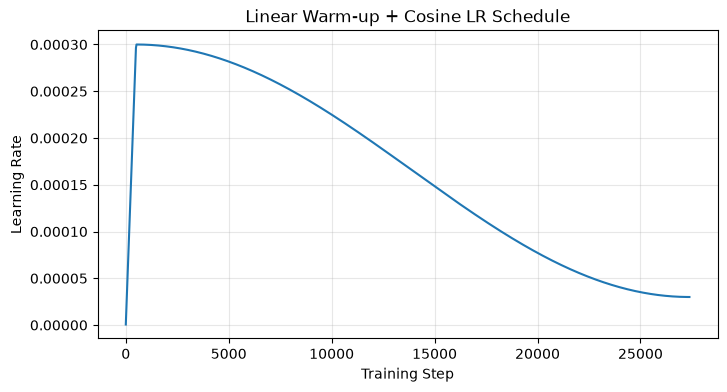

Initial LR : 6e-07
Warmup LR  : 0.0003
Final LR   : 3.0000000922029872e-05


In [61]:
sample_steps = np.linspace(
    0,
    TOTAL_STEPS - 1,
    1000,
    dtype=int
)

sample_lrs = [
    get_learning_rate(step)
    for step in sample_steps
]

plt.figure(figsize=(8, 4))
plt.plot(sample_steps, sample_lrs)
plt.xlabel("Training Step")
plt.ylabel("Learning Rate")
plt.title("Linear Warm-up + Cosine LR Schedule")
plt.grid(alpha=0.3)
plt.show()

print("Initial LR :", get_learning_rate(0))
print("Warmup LR  :", get_learning_rate(WARMUP_STEPS - 1))
print("Final LR   :", get_learning_rate(TOTAL_STEPS - 1))

In [62]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_tokens = 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16
        ):
            logits, loss = model(xb, yb)

        total_loss += loss.item() * yb.numel()

        predictions = logits.argmax(dim=-1)

        total_correct += (
            predictions == yb
        ).sum().item()

        total_tokens += yb.numel()

    avg_loss = total_loss / total_tokens
    accuracy = total_correct / total_tokens

    model.train()

    return avg_loss, accuracy

In [63]:
BENCHMARK_STEPS = 200

model.train()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

benchmark_start = time.time()
benchmark_tokens = 0

optimizer.zero_grad(set_to_none=True)

for step, (xb, yb) in enumerate(train_loader):

    if step >= BENCHMARK_STEPS:
        break

    xb = xb.to(device, non_blocking=True)
    yb = yb.to(device, non_blocking=True)

    lr = get_learning_rate(step)

    for param_group in optimizer.param_groups:
        param_group["lr"] = lr

    with torch.autocast(
        device_type="cuda",
        dtype=torch.bfloat16
    ):
        logits, loss = model(xb, yb)

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=1.0
    )

    optimizer.step()
    optimizer.zero_grad(set_to_none=True)

    benchmark_tokens += yb.numel()

torch.cuda.synchronize()

benchmark_time = time.time() - benchmark_start

tokens_per_sec = benchmark_tokens / benchmark_time

peak_memory_gb = (
    torch.cuda.max_memory_allocated()
    / 1024**3
)

estimated_epoch_sec = (
    benchmark_time
    / BENCHMARK_STEPS
    * len(train_loader)
)

estimated_20_epoch_hours = (
    estimated_epoch_sec
    * EPOCHS
    / 3600
)

print("Benchmark steps       :", BENCHMARK_STEPS)
print("Benchmark time        :", round(benchmark_time, 2), "sec")
print("Training tokens/sec   :", f"{tokens_per_sec:,.0f}")
print("Peak GPU memory       :", round(peak_memory_gb, 2), "GB")

print(
    "Estimated epoch time  :",
    round(estimated_epoch_sec / 60, 2),
    "minutes"
)

print(
    f"Estimated {EPOCHS}-epoch time:",
    round(estimated_20_epoch_hours, 2),
    "hours"
)

Benchmark steps       : 200
Benchmark time        : 6.53 sec
Training tokens/sec   : 1,003,176
Peak GPU memory       : 3.57 GB
Estimated epoch time  : 1.49 minutes
Estimated 10-epoch time: 0.25 hours


In [64]:
# ------------------------------------------------------------
# CLEAN RESET AFTER BENCHMARK
# ------------------------------------------------------------

# Re-seed so the official run starts reproducibly
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Clear benchmark/test objects if they exist
for name in [
    "model", "optimizer",
    "attention_test", "block_test",
    "dummy_x", "dummy_out",
    "xb", "yb"
]:
    if name in globals():
        del globals()[name]

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

# Recreate model from scratch
model = GPTLanguageModel(
    vocab_size=VOCAB_SIZE,
    block_size=BLOCK_SIZE,
    n_embd=N_EMBD,
    n_head=N_HEAD,
    n_layer=N_LAYER,
    dropout=DROPOUT
).to(device)

# Recreate optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.95)
)

# IMPORTANT: recompute this for 10 epochs
TOTAL_STEPS = EPOCHS * len(train_loader)

print("Official training configuration")
print("--------------------------------")
print("Epochs              :", EPOCHS)
print("Steps / epoch       :", len(train_loader))
print("Total steps         :", TOTAL_STEPS)
print("Warmup steps        :", WARMUP_STEPS)
print("Model parameters    :", f"{sum(p.numel() for p in model.parameters()):,}")
print("GPU                 :", torch.cuda.get_device_name(0))

Official training configuration
--------------------------------
Epochs              : 10
Steps / epoch       : 2738
Total steps         : 27380
Warmup steps        : 500
Model parameters    : 3,278,336
GPU                 : NVIDIA GeForce RTX 5090


In [66]:
RAW_LOG_DIR = PROJECT_ROOT / "reproducibility" / "raw_logs"
RAW_LOG_DIR.mkdir(parents=True, exist_ok=True)

LOG_PATH = RAW_LOG_DIR / "task1_llm_naveen_training_raw.txt"

BEST_CHECKPOINT_PATH = CHECKPOINT_DIR / "task1_gpt_best.pt"
LAST_CHECKPOINT_PATH = CHECKPOINT_DIR / "task1_gpt_last.pt"

HISTORY_PATH = MEMBER_DIR / "task1_training_history.csv"

print("Raw log    :", LOG_PATH)
print("Best model :", BEST_CHECKPOINT_PATH)
print("Last model :", LAST_CHECKPOINT_PATH)
print("History CSV:", HISTORY_PATH)

Raw log    : D:\DATA266_Lab1\reproducibility\raw_logs\task1_llm_naveen_training_raw.txt
Best model : D:\DATA266_Lab1\task1_llm\naveen\checkpoints\task1_gpt_best.pt
Last model : D:\DATA266_Lab1\task1_llm\naveen\checkpoints\task1_gpt_last.pt
History CSV: D:\DATA266_Lab1\task1_llm\naveen\task1_training_history.csv


In [67]:
training_history = []

best_val_loss = float("inf")
global_step = 0

training_start_time = time.time()

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

# Start a fresh raw log
with open(LOG_PATH, "w", encoding="utf-8") as log_file:
    log_file.write("DATA266 Lab 1 - Task 1 Official Training Run\n")
    log_file.write("=" * 70 + "\n")
    log_file.write(f"Epochs: {EPOCHS}\n")
    log_file.write(f"Batch size: {BATCH_SIZE}\n")
    log_file.write(f"Block size: {BLOCK_SIZE}\n")
    log_file.write(f"Embedding dimension: {N_EMBD}\n")
    log_file.write(f"Heads: {N_HEAD}\n")
    log_file.write(f"Layers: {N_LAYER}\n")
    log_file.write(f"Learning rate: {LEARNING_RATE}\n")
    log_file.write(f"Warmup steps: {WARMUP_STEPS}\n")
    log_file.write(f"GPU: {torch.cuda.get_device_name(0)}\n")
    log_file.write("=" * 70 + "\n\n")


for epoch in range(1, EPOCHS + 1):

    model.train()

    epoch_start = time.time()

    running_loss = 0.0
    total_train_tokens = 0
    grad_norm_sum = 0.0
    grad_norm_count = 0

    progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch}/{EPOCHS}"
    )

    for xb, yb in progress:

        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        # Update learning rate
        current_lr = get_learning_rate(global_step)

        for param_group in optimizer.param_groups:
            param_group["lr"] = current_lr

        optimizer.zero_grad(set_to_none=True)

        # BF16 mixed precision
        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16
        ):
            logits, loss = model(xb, yb)

        loss.backward()

        grad_norm = torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        num_tokens = yb.numel()

        running_loss += loss.item() * num_tokens
        total_train_tokens += num_tokens

        grad_norm_sum += float(grad_norm)
        grad_norm_count += 1

        global_step += 1

        progress.set_postfix(
            loss=f"{loss.item():.4f}",
            lr=f"{current_lr:.2e}"
        )

    torch.cuda.synchronize()

    epoch_train_time = time.time() - epoch_start

    train_loss = running_loss / total_train_tokens

    # -------------------------
    # Validation
    # -------------------------
    val_start = time.time()

    val_loss, val_accuracy = evaluate(
        model,
        val_loader
    )

    torch.cuda.synchronize()

    val_time = time.time() - val_start

    # -------------------------
    # Derived metrics
    # -------------------------
    perplexity = math.exp(val_loss)
    bits_per_character = val_loss / math.log(2)

    generalization_gap = val_loss - train_loss

    avg_grad_norm = (
        grad_norm_sum / grad_norm_count
    )

    tokens_per_sec = (
        total_train_tokens / epoch_train_time
    )

    peak_memory_gb = (
        torch.cuda.max_memory_allocated()
        / 1024**3
    )

    epoch_result = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_perplexity": perplexity,
        "bits_per_character": bits_per_character,
        "generalization_gap": generalization_gap,
        "val_top1_accuracy": val_accuracy,
        "avg_gradient_norm": avg_grad_norm,
        "learning_rate": current_lr,
        "training_tokens_per_sec": tokens_per_sec,
        "epoch_train_seconds": epoch_train_time,
        "validation_seconds": val_time,
        "peak_gpu_memory_gb": peak_memory_gb
    }

    training_history.append(epoch_result)

    # Save CSV after EVERY epoch
    pd.DataFrame(training_history).to_csv(
        HISTORY_PATH,
        index=False
    )

    # -------------------------
    # Save best checkpoint
    # -------------------------
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": val_loss,
                "train_loss": train_loss,

                "config": {
                    "vocab_size": VOCAB_SIZE,
                    "block_size": BLOCK_SIZE,
                    "n_embd": N_EMBD,
                    "n_head": N_HEAD,
                    "n_layer": N_LAYER,
                    "dropout": DROPOUT
                },

                "char_to_idx": char_to_idx,
                "idx_to_char": idx_to_char
            },
            BEST_CHECKPOINT_PATH
        )

        best_marker = " <-- BEST"
    else:
        best_marker = ""

    # Last checkpoint
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": val_loss,
            "global_step": global_step
        },
        LAST_CHECKPOINT_PATH
    )

    # -------------------------
    # Print epoch result
    # -------------------------
    summary = (
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"PPL: {perplexity:.2f} | "
        f"BPC: {bits_per_character:.3f} | "
        f"Top-1: {val_accuracy*100:.2f}% | "
        f"Gap: {generalization_gap:.4f} | "
        f"Grad: {avg_grad_norm:.3f} | "
        f"Tokens/s: {tokens_per_sec:,.0f} | "
        f"Time: {epoch_train_time/60:.2f} min"
        f"{best_marker}"
    )

    print("\n" + summary + "\n")

    # Append raw evidence log
    with open(LOG_PATH, "a", encoding="utf-8") as log_file:
        log_file.write(summary + "\n")


torch.cuda.synchronize()

total_training_time = (
    time.time() - training_start_time
)

print("=" * 80)
print("TRAINING COMPLETE")
print("=" * 80)

print(
    "Total training time:",
    round(total_training_time / 60, 2),
    "minutes"
)

print(
    "Best validation loss:",
    round(best_val_loss, 4)
)

print(
    "Peak GPU memory:",
    round(
        torch.cuda.max_memory_allocated()
        / 1024**3,
        2
    ),
    "GB"
)

print("Best checkpoint:", BEST_CHECKPOINT_PATH)
print("History CSV    :", HISTORY_PATH)
print("Raw log        :", LOG_PATH)

Epoch 1/10: 100%|██████████| 2738/2738 [01:38<00:00, 27.70it/s, loss=0.9131, lr=2.95e-04]



Epoch 01/10 | Train Loss: 1.4190 | Val Loss: 0.8544 | PPL: 2.35 | BPC: 1.233 | Top-1: 73.14% | Gap: -0.5646 | Grad: 0.988 | Tokens/s: 907,808 | Time: 1.65 min <-- BEST



Epoch 2/10: 100%|██████████| 2738/2738 [01:38<00:00, 27.72it/s, loss=0.7906, lr=2.78e-04]



Epoch 02/10 | Train Loss: 0.8400 | Val Loss: 0.7421 | PPL: 2.10 | BPC: 1.071 | Top-1: 76.55% | Gap: -0.0980 | Grad: 0.510 | Tokens/s: 908,246 | Time: 1.65 min <-- BEST



Epoch 3/10: 100%|██████████| 2738/2738 [01:38<00:00, 27.75it/s, loss=0.7306, lr=2.49e-04]


...


Epoch 08/10 | Train Loss: 0.6727 | Val Loss: 0.6345 | PPL: 1.89 | BPC: 0.915 | Top-1: 79.80% | Gap: -0.0382 | Grad: 0.341 | Tokens/s: 906,492 | Time: 1.65 min <-- BEST



Epoch 9/10: 100%|██████████| 2738/2738 [01:38<00:00, 27.79it/s, loss=0.6477, lr=3.69e-05]



Epoch 09/10 | Train Loss: 0.6669 | Val Loss: 0.6312 | PPL: 1.88 | BPC: 0.911 | Top-1: 79.91% | Gap: -0.0357 | Grad: 0.345 | Tokens/s: 910,595 | Time: 1.64 min <-- BEST



Epoch 10/10: 100%|██████████| 2738/2738 [01:38<00:00, 27.88it/s, loss=0.6574, lr=3.00e-05]



Epoch 10/10 | Train Loss: 0.6634 | Val Loss: 0.6285 | PPL: 1.87 | BPC: 0.907 | Top-1: 79.98% | Gap: -0.0349 | Grad: 0.349 | Tokens/s: 913,561 | Time: 1.64 min <-- BEST

TRAINING COMPLETE
Total training time: 17.02 minutes
Best validation loss: 0.6285
Peak GPU memory: 3.57 GB
Best checkpoint: D:\DATA266_Lab1\task1_llm\naveen\checkpoints\task1_gpt_best.pt
History CSV    : D:\DATA266_Lab1\task1_llm\naveen\task1_training_history.csv
Raw log        : D:\DATA266_Lab1\reproducibility\raw_logs\task1_llm_naveen_training_raw.txt


In [68]:
history_df = pd.read_csv(HISTORY_PATH)

display(history_df.round(4))

best_row = history_df.loc[
    history_df["val_loss"].idxmin()
]

print("\nBest epoch:", int(best_row["epoch"]))
print("Best train loss:", round(best_row["train_loss"], 4))
print("Best validation loss:", round(best_row["val_loss"], 4))
print("Best perplexity:", round(best_row["val_perplexity"], 4))
print("Best BPC:", round(best_row["bits_per_character"], 4))
print(
    "Best Top-1 accuracy:",
    round(best_row["val_top1_accuracy"] * 100, 2),
    "%"
)
print(
    "Generalization gap:",
    round(best_row["generalization_gap"], 4)
)

,epoch,train_loss,val_loss,val_perplexity,bits_per_character,generalization_gap,val_top1_accuracy,avg_gradient_norm,learning_rate,training_tokens_per_sec,epoch_train_seconds,validation_seconds,peak_gpu_memory_gb
0,1,1.4190,0.8544,2.3499,1.2326,-0.5646,0.7314,0.9878,0.0003,907807.6404,98.8302,3.3671,3.5695
1,2,0.8400,0.7421,2.1002,1.0706,-0.0980,0.7655,0.5101,0.0003,908246.4352,98.7824,3.3456,3.5695
2,3,0.7627,0.6990,2.0117,1.0084,-0.0637,0.7787,0.3999,0.0002,909330.0260,98.6647,3.3184,3.5695
3,4,0.7281,0.6766,1.9671,0.9761,-0.0515,0.7853,0.3595,0.0002,909478.3605,98.6486,3.3457,3.5695
4,5,0.7070,0.6605,1.9357,0.9528,-0.0465,0.7902,0.3430,0.0002,907993.9273,98.8099,3.3192,3.5695
5,6,0.6919,0.6493,1.9141,0.9367,-0.0427,0.7935,0.3375,0.0001,909720.6853,98.6223,3.3632,3.5695
6,7,0.6809,0.6410,1.8985,0.9248,-0.0399,0.7960,0.3375,0.0001,910966.5836,98.4875,3.3281,3.5695
7,8,0.6727,0.6345,1.8860,0.9153,-0.0382,0.7980,0.3411,0.0001,906491.8025,98.9736,3.3253,3.5695
8,9,0.6669,0.6312,1.8799,0.9107,-0.0357,0.7991,0.3449,0.0000,910594.9203,98.5277,3.3299,3.5695
9,10,0.6634,0.6285,1.8748,0.9067,-0.0349,0.7998,0.3488,0.0000,913560.7085,98.2078,3.3815,3.5695



Best epoch: 10
Best train loss: 0.6634
Best validation loss: 0.6285
Best perplexity: 1.8748
Best BPC: 0.9067
Best Top-1 accuracy: 79.98 %
Generalization gap: -0.0349


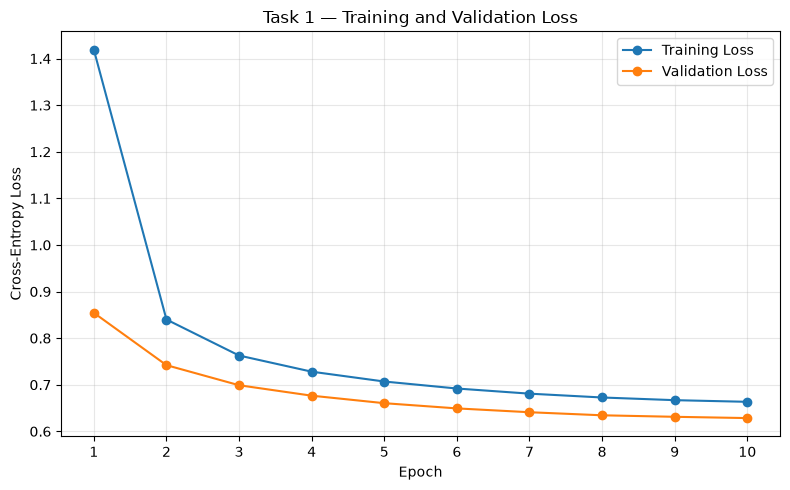

Saved: D:\DATA266_Lab1\task1_llm\naveen\outputs\train_val_loss_curve.png


In [69]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Task 1 — Training and Validation Loss")
plt.xticks(history_df["epoch"])
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

loss_curve_path = OUTPUT_DIR / "train_val_loss_curve.png"

plt.savefig(
    loss_curve_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", loss_curve_path)

In [70]:
checkpoint = torch.load(
    BEST_CHECKPOINT_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Loaded best checkpoint.")
print("Best epoch   :", checkpoint["epoch"])
print("Train loss   :", round(checkpoint["train_loss"], 4))
print("Val loss     :", round(checkpoint["val_loss"], 4))

Loaded best checkpoint.
Best epoch   : 10
Train loss   : 0.6634
Val loss     : 0.6285


In [71]:
@torch.no_grad()
def generate_text(
    model,
    prompt,
    max_new_tokens=500,
    temperature=0.8,
    greedy=False
):
    model.eval()

    token_ids = encode(prompt)

    idx = torch.tensor(
        token_ids,
        dtype=torch.long,
        device=device
    ).unsqueeze(0)

    generated_count = 0

    torch.cuda.synchronize()
    start_time = time.time()

    for _ in range(max_new_tokens):

        # Only use the most recent BLOCK_SIZE characters
        idx_cond = idx[:, -BLOCK_SIZE:]

        logits, _ = model(idx_cond)

        # Only predict the next character
        logits = logits[:, -1, :]

        if greedy:
            next_token = torch.argmax(
                logits,
                dim=-1,
                keepdim=True
            )

        else:
            logits = logits / temperature

            probs = F.softmax(
                logits,
                dim=-1
            )

            next_token = torch.multinomial(
                probs,
                num_samples=1
            )

        idx = torch.cat(
            [idx, next_token],
            dim=1
        )

        generated_count += 1

    torch.cuda.synchronize()

    elapsed = time.time() - start_time

    generation_speed = (
        generated_count / elapsed
    )

    generated_text = decode(
        idx[0].tolist()
    )

    return generated_text, generation_speed

In [72]:
prompt = "Once upon a time"

generated_text, generation_speed = generate_text(
    model,
    prompt=prompt,
    max_new_tokens=700,
    temperature=0.8
)

print(generated_text)

print(
    "\nGeneration speed:",
    round(generation_speed, 2),
    "characters/sec"
)

Once upon a time, in a small town, there lived a little boy named Tim. Tim liked to play with his toys all day. One day, he found a big stick in the garage. He was very excited and wanted to play with it.

Tim started to weep his toy car and the stick was so much fun that it didn't work out loud. He was so excited to have it to see what was inside. The stick told Tim that it was gone. The little boy was so happy. He thanked Tim for helping him with others. 

From that day on, Tim was never lonely again. He knew that he would always pay for a day of step.

Once upon a time, there was a little girl named Lily. She loved to watch the birds fly in the sky, leaving them inside the garden. One day, she found a bi

Generation speed: 375.18 characters/sec


In [73]:
greedy_text, greedy_speed = generate_text(
    model,
    prompt="Once upon a time",
    max_new_tokens=700,
    greedy=True
)

print(greedy_text)

print(
    "\nGreedy generation speed:",
    round(greedy_speed, 2),
    "characters/sec"
)

Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she saw a big tree with a long tail on it. She wanted to pick it up and see what was inside.

Lily went to the tree and said, "Mommy, can I pick it up?" Her mommy said, "Yes, you can pick it up." Lily was so excited to pick it up and put it in her pocket. She put it in her pocket and went to the tree.

When they got home, Lily saw a big bird with a long neck. She wanted to fly it and see what was inside. She asked her mom if she could fly in the sky. Her mom said yes, but Lily didn't want to fly anymore. She said she wanted to fly away from the bird.

Lily was sad and didn't know what to do. She decided

Greedy generation speed: 440.36 characters/sec


In [74]:
@torch.no_grad()
def evaluate_full(model, loader):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_tokens = 0

    for xb, yb in tqdm(loader, desc="Final evaluation"):
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16
        ):
            logits, loss = model(xb, yb)

        num_tokens = yb.numel()

        total_loss += loss.item() * num_tokens
        total_correct += (logits.argmax(-1) == yb).sum().item()
        total_tokens += num_tokens

    return (
        total_loss / total_tokens,
        total_correct / total_tokens
    )


final_train_loss, final_train_accuracy = evaluate_full(
    model,
    train_loader
)

final_val_loss, final_val_accuracy = evaluate_full(
    model,
    val_loader
)

final_generalization_gap = final_val_loss - final_train_loss
final_perplexity = math.exp(final_val_loss)
final_bpc = final_val_loss / math.log(2)

print("\nFINAL COMPARABLE METRICS")
print("------------------------")
print("Train loss         :", round(final_train_loss, 4))
print("Validation loss    :", round(final_val_loss, 4))
print("Generalization gap :", round(final_generalization_gap, 4))
print("Validation PPL     :", round(final_perplexity, 4))
print("Validation BPC     :", round(final_bpc, 4))
print("Train Top-1        :", round(final_train_accuracy * 100, 2), "%")
print("Validation Top-1   :", round(final_val_accuracy * 100, 2), "%")

Final evaluation: 100%|██████████| 274/274 [00:03<00:00, 78.38it/s]


FINAL COMPARABLE METRICS
------------------------
Train loss         : 0.619
Validation loss    : 0.6285
Generalization gap : 0.0095
Validation PPL     : 1.8748
Validation BPC     : 0.9067
Train Top-1        : 80.22 %
Validation Top-1   : 79.98 %


In [75]:
evaluation_prompts = [
    "Once upon a time",
    "One day, a little girl",
    "There was a little boy",
    "In a small village",
    "The dog looked at",
    "Lily went outside",
    "Tom was very excited",
    "The next morning",
]

generated_samples = []

for i, prompt in enumerate(evaluation_prompts, start=1):

    text, speed = generate_text(
        model,
        prompt=prompt,
        max_new_tokens=600,
        temperature=0.8,
        greedy=False
    )

    generated_samples.append({
        "sample": i,
        "prompt": prompt,
        "text": text,
        "generation_chars_per_sec": speed
    })

    print(f"Sample {i} complete.")

samples_df = pd.DataFrame(generated_samples)

samples_path = OUTPUT_DIR / "generated_samples.csv"
samples_df.to_csv(samples_path, index=False)

print("\nSaved:", samples_path)
print(
    "Average generation speed:",
    round(samples_df["generation_chars_per_sec"].mean(), 2),
    "chars/sec"
)

Sample 1 complete.
Sample 2 complete.
Sample 3 complete.
Sample 4 complete.
Sample 5 complete.
Sample 6 complete.
Sample 7 complete.
Sample 8 complete.

Saved: D:\DATA266_Lab1\task1_llm\naveen\outputs\generated_samples.csv
Average generation speed: 404.56 chars/sec


In [76]:
import re
from collections import Counter


def distinct_n(sequence, n):
    ngrams = [
        tuple(sequence[i:i+n])
        for i in range(len(sequence) - n + 1)
    ]

    if not ngrams:
        return 0.0

    return len(set(ngrams)) / len(ngrams)


def repeated_ngram_rate(sequence, n=4):
    ngrams = [
        tuple(sequence[i:i+n])
        for i in range(len(sequence) - n + 1)
    ]

    if not ngrams:
        return 0.0

    counts = Counter(ngrams)

    repeated_instances = sum(
        count - 1
        for count in counts.values()
        if count > 1
    )

    return repeated_instances / len(ngrams)


combined_generation = "\n".join(samples_df["text"])

# Character-token metrics
char_sequence = list(combined_generation)

char_distinct_1 = distinct_n(char_sequence, 1)
char_distinct_2 = distinct_n(char_sequence, 2)
char_distinct_3 = distinct_n(char_sequence, 3)
char_repeat_4 = repeated_ngram_rate(char_sequence, 4)

# Additional word-level metrics
word_sequence = re.findall(
    r"\b\w+\b",
    combined_generation.lower()
)

word_distinct_1 = distinct_n(word_sequence, 1)
word_distinct_2 = distinct_n(word_sequence, 2)
word_distinct_3 = distinct_n(word_sequence, 3)
word_repeat_4 = repeated_ngram_rate(word_sequence, 4)

print("CHARACTER-LEVEL METRICS")
print("-----------------------")
print("Distinct-1       :", round(char_distinct_1, 4))
print("Distinct-2       :", round(char_distinct_2, 4))
print("Distinct-3       :", round(char_distinct_3, 4))
print("Repeated 4-gram  :", round(char_repeat_4, 4))

print("\nWORD-LEVEL METRICS (additional)")
print("-------------------------------")
print("Distinct-1       :", round(word_distinct_1, 4))
print("Distinct-2       :", round(word_distinct_2, 4))
print("Distinct-3       :", round(word_distinct_3, 4))
print("Repeated 4-gram  :", round(word_repeat_4, 4))

CHARACTER-LEVEL METRICS
-----------------------
Distinct-1       : 0.0097
Distinct-2       : 0.0824
Distinct-3       : 0.234
Repeated 4-gram  : 0.6072

WORD-LEVEL METRICS (additional)
-------------------------------
Distinct-1       : 0.2449
Distinct-2       : 0.6848
Distinct-3       : 0.8685
Repeated 4-gram  : 0.0712


In [77]:
parameter_count = sum(
    p.numel()
    for p in model.parameters()
)

best_epoch_row = history_df.loc[
    history_df["val_loss"].idxmin()
]

avg_training_tokens_sec = history_df[
    "training_tokens_per_sec"
].mean()

avg_generation_speed = samples_df[
    "generation_chars_per_sec"
].mean()

metrics_report = pd.DataFrame([
    {
        "best_epoch": int(checkpoint["epoch"]),

        "training_cross_entropy_loss":
            final_train_loss,

        "validation_cross_entropy_loss":
            final_val_loss,

        "perplexity":
            final_perplexity,

        "bits_per_character":
            final_bpc,

        "generalization_gap":
            final_generalization_gap,

        "top1_next_character_accuracy":
            final_val_accuracy,

        "distinct_1_char":
            char_distinct_1,

        "distinct_2_char":
            char_distinct_2,

        "distinct_3_char":
            char_distinct_3,

        "repeated_4gram_rate_char":
            char_repeat_4,

        "distinct_1_word":
            word_distinct_1,

        "distinct_2_word":
            word_distinct_2,

        "distinct_3_word":
            word_distinct_3,

        "repeated_4gram_rate_word":
            word_repeat_4,

        "average_gradient_norm":
            best_epoch_row["avg_gradient_norm"],

        "nan_count":
            0,

        "parameter_count":
            parameter_count,

        "training_tokens_per_sec":
            avg_training_tokens_sec,

        "generation_chars_per_sec":
            avg_generation_speed,

        "peak_gpu_memory_gb":
            history_df["peak_gpu_memory_gb"].max(),

        "total_training_time_minutes":
            history_df["epoch_train_seconds"].sum() / 60
            + history_df["validation_seconds"].sum() / 60,

        "gpu":
            torch.cuda.get_device_name(0)
    }
])

METRICS_PATH = MEMBER_DIR / "metrics_report.csv"

metrics_report.to_csv(
    METRICS_PATH,
    index=False
)

display(metrics_report.T)

print("\nSaved:", METRICS_PATH)

,0
best_epoch,10
training_cross_entropy_loss,0.619035
validation_cross_entropy_loss,0.62849
perplexity,1.874778
bits_per_character,0.90672
generalization_gap,0.009456
top1_next_character_accuracy,0.79982
distinct_1_char,0.009687
distinct_2_char,0.082358
distinct_3_char,0.234



Saved: D:\DATA266_Lab1\task1_llm\naveen\metrics_report.csv


In [78]:
# Character-level model:
# one generated character corresponds to one model token.

metrics_report["generation_tokens_per_sec"] = (
    metrics_report["generation_chars_per_sec"]
)

# Epoch-level stability indicators
train_loss_increases = int(
    (history_df["train_loss"].diff() > 0).sum()
)

val_loss_increases = int(
    (history_df["val_loss"].diff() > 0).sum()
)

metrics_report["train_loss_epoch_increases"] = train_loss_increases
metrics_report["val_loss_epoch_increases"] = val_loss_increases
metrics_report["training_stable"] = (
    (metrics_report["nan_count"].iloc[0] == 0)
    and train_loss_increases == 0
    and val_loss_increases == 0
)

metrics_report.to_csv(
    METRICS_PATH,
    index=False
)

display(metrics_report.T)

print("\nUpdated:", METRICS_PATH)
print("Train-loss epoch increases:", train_loss_increases)
print("Val-loss epoch increases  :", val_loss_increases)

,0
best_epoch,10
training_cross_entropy_loss,0.619035
validation_cross_entropy_loss,0.62849
perplexity,1.874778
bits_per_character,0.90672
generalization_gap,0.009456
top1_next_character_accuracy,0.79982
distinct_1_char,0.009687
distinct_2_char,0.082358
distinct_3_char,0.234



Updated: D:\DATA266_Lab1\task1_llm\naveen\metrics_report.csv
Train-loss epoch increases: 0
Val-loss epoch increases  : 0


In [79]:
failure_analysis_path = MEMBER_DIR / "failure_analysis.md"

failure_analysis_text = """# Task 1 — Sequence Model Failure Analysis

## Failure Case 1 — Semantic Inconsistency

**Generated snippet:**

> "She saw a big tree with a long tail on it. She wanted to pick it up and see what was inside."

**Failure type:** Loss of coherence / semantic inconsistency

**Observation:**  
The sentence is grammatically structured, but the described object behavior is not logically consistent. A tree is described as having a long tail and as something that can be picked up. This shows that the model learned common sentence patterns more strongly than physical or semantic consistency.

---

## Failure Case 2 — Nonsensical Phrase

**Generated snippet:**

> "He knew that he would always pay for a day of step."

**Failure type:** Broken semantics / incoherent phrase

**Observation:**  
The model produces a sentence with valid local grammar, but the phrase "pay for a day of step" has no clear meaning. This suggests that character-level prediction can create fluent-looking syntax without preserving higher-level meaning.

---

## Failure Case 3 — Template-Like Repetition

**Generated behavior:**

> "She wanted to ... and see what was inside."

Similar sentence structures appeared repeatedly in greedy generation.

**Failure type:** Repetition / low-diversity decoding

**Observation:**  
Greedy decoding repeatedly selects the highest-probability next character and tends to fall into common TinyStories-style sentence templates. Temperature sampling produced more variation, while greedy decoding was more deterministic and repetitive.

---

## Overall Observation

The model produces mostly grammatical TinyStories-style text, but occasional semantic inconsistencies and repetitive sentence templates remain. Temperature sampling improves diversity compared with greedy decoding, although it can also introduce less coherent continuations.
"""

failure_analysis_path.write_text(
    failure_analysis_text,
    encoding="utf-8"
)

print("Saved:", failure_analysis_path)
print()
print(failure_analysis_path.read_text(encoding="utf-8"))

Saved: D:\DATA266_Lab1\task1_llm\naveen\failure_analysis.md

# Task 1 — Sequence Model Failure Analysis

## Failure Case 1 — Semantic Inconsistency

**Generated snippet:**

> "She saw a big tree with a long tail on it. She wanted to pick it up and see what was inside."

**Failure type:** Loss of coherence / semantic inconsistency

**Observation:**  
The sentence is grammatically structured, but the described object behavior is not logically consistent. A tree is described as having a long tail and as something that can be picked up. This shows that the model learned common sentence patterns more strongly than physical or semantic consistency.

---

## Failure Case 2 — Nonsensical Phrase

**Generated snippet:**

> "He knew that he would always pay for a day of step."

**Failure type:** Broken semantics / incoherent phrase

**Observation:**  
The model produces a sentence with valid local grammar, but the phrase "pay for a day of step" has no clear meaning. This suggests that character-l

In [80]:
results_path = MEMBER_DIR / "results.md"

results_text = f"""# DATA266 Lab 1 — Task 1 Results

## Model

GPT-style decoder-only character language model implemented from scratch in PyTorch.

### Architecture

- Character vocabulary size: {VOCAB_SIZE}
- Context length: {BLOCK_SIZE}
- Embedding dimension: {N_EMBD}
- Attention heads: {N_HEAD}
- Dimension per head: {N_EMBD // N_HEAD}
- Transformer blocks: {N_LAYER}
- Feed-forward hidden dimension: {4 * N_EMBD}
- Dropout: {DROPOUT}
- Learnable token embeddings
- Learnable positional embeddings
- Pre-LayerNorm Transformer blocks
- Causal multi-head self-attention implemented manually
- Residual connections
- GELU feed-forward networks
- Linear language-model head
- Parameters: {sum(p.numel() for p in model.parameters()):,}

No nn.MultiheadAttention, nn.Transformer, or pretrained Transformer model was used.

## Architecture Rationale

A context length of 256 characters was selected to provide multiple sentences of context while keeping the quadratic computational cost of self-attention manageable.

The 256-dimensional embedding is divided across 8 attention heads, giving 32 dimensions per head. Four Transformer blocks provide multiple stages of attention and nonlinear transformation while keeping the model small enough for efficient experimentation.

## Dataset

Dataset: TinyStories

Individual deterministic split:

- Training stories: 100,000
- Validation stories: 10,000
- Training characters: {len(train_ids):,}
- Validation characters: {len(val_ids):,}
- Final vocabulary size: {VOCAB_SIZE}
- Validation-only unseen characters: 3

Validation-only unseen characters were mapped to a reserved <UNK> token.

## Training Configuration

- Epochs: {EPOCHS}
- Batch size: {BATCH_SIZE}
- Optimizer: AdamW
- Initial learning rate: {LEARNING_RATE}
- Minimum learning rate: {MIN_LR}
- Warm-up steps: {WARMUP_STEPS}
- Scheduler: linear warm-up followed by cosine decay
- Weight decay: {WEIGHT_DECAY}
- Gradient clipping: 1.0
- Mixed precision: BF16
- Seed: {SEED}

## Final Evaluation

| Metric | Result |
|---|---:|
| Training cross-entropy loss | {final_train_loss:.4f} |
| Validation cross-entropy loss | {final_val_loss:.4f} |
| Generalization gap | {final_generalization_gap:.4f} |
| Validation perplexity | {final_perplexity:.4f} |
| Bits per character | {final_bpc:.4f} |
| Train Top-1 accuracy | {final_train_accuracy * 100:.2f}% |
| Validation Top-1 accuracy | {final_val_accuracy * 100:.2f}% |
| Character Distinct-1 | {char_distinct_1:.4f} |
| Character Distinct-2 | {char_distinct_2:.4f} |
| Character Distinct-3 | {char_distinct_3:.4f} |
| Character repeated 4-gram rate | {char_repeat_4:.4f} |
| Word Distinct-1 | {word_distinct_1:.4f} |
| Word Distinct-2 | {word_distinct_2:.4f} |
| Word Distinct-3 | {word_distinct_3:.4f} |
| Word repeated 4-gram rate | {word_repeat_4:.4f} |
| Parameter count | {sum(p.numel() for p in model.parameters()):,} |
| Average training throughput | {metrics_report["training_tokens_per_sec"].iloc[0]:,.0f} tokens/sec |
| Average generation throughput | {metrics_report["generation_tokens_per_sec"].iloc[0]:.2f} tokens/sec |
| Peak GPU memory | {metrics_report["peak_gpu_memory_gb"].iloc[0]:.2f} GB |
| Training time | {metrics_report["total_training_time_minutes"].iloc[0]:.2f} min |
| NaN count | 0 |

## Training Stability

Training and validation loss decreased across all 10 epochs. No NaN values were observed during training. Gradient norms remained finite throughout the run.

## Generation

Both greedy decoding and temperature sampling were evaluated.

Greedy decoding produced more deterministic and template-like outputs. Temperature sampling produced greater variety but occasionally reduced semantic coherence.

Generated examples are stored in:

`outputs/generated_samples.csv`

The detailed three-case analysis is stored in:

`failure_analysis.md`

## Hardware

- GPU: NVIDIA GeForce RTX 5090
- Peak allocated GPU memory: {metrics_report["peak_gpu_memory_gb"].iloc[0]:.2f} GB
"""

results_path.write_text(
    results_text,
    encoding="utf-8"
)

print("Saved:", results_path)

Saved: D:\DATA266_Lab1\task1_llm\naveen\results.md


In [81]:
manifest_path = (
    PROJECT_ROOT
    / "reproducibility"
    / "manifests"
    / "task1_naveen_manifest.txt"
)

manifest_text = f"""DATA266 Lab 1 — Task 1 Manifest

Student: Naveen Aravapalli
Task: GPT-Style LLM From Scratch

Best checkpoint:
{BEST_CHECKPOINT_PATH}

Best epoch:
{checkpoint["epoch"]}

Best validation loss:
{final_val_loss:.6f}

Metrics:
{METRICS_PATH}

Training history:
{HISTORY_PATH}

Raw training log:
{LOG_PATH}

Loss curve:
{OUTPUT_DIR / "train_val_loss_curve.png"}

Generated samples:
{OUTPUT_DIR / "generated_samples.csv"}

Failure analysis:
{failure_analysis_path}

Results summary:
{results_path}

Notebook:
{SRC_DIR / "Task1_LLM_Naveen.ipynb"}

GPU:
{torch.cuda.get_device_name(0)}
"""

manifest_path.write_text(
    manifest_text,
    encoding="utf-8"
)

print("Saved:", manifest_path)

Saved: D:\DATA266_Lab1\reproducibility\manifests\task1_naveen_manifest.txt
